In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from skimage.io import imread
from google.colab import files  # Only needed for Google Colab
import io

# Upload the image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get the uploaded file name

# Load and process the image
image = imread(io.BytesIO(uploaded[image_path]), as_gray=True)  # Convert to grayscale

# Define an initial contour (assuming the object is centered)
s = np.linspace(0, 2*np.pi, 100)  # 100 points around the contour
x = image.shape[1]//2 + 100 * np.cos(s)  # Initial X-coordinates
y = image.shape[0]//2 + 100 * np.sin(s)  # Initial Y-coordinates
init_contour = np.array([x, y]).T

# Apply Gaussian smoothing to reduce noise
smoothed_image = gaussian(image, sigma=1)






Saving heartin.jpeg to heartin.jpeg


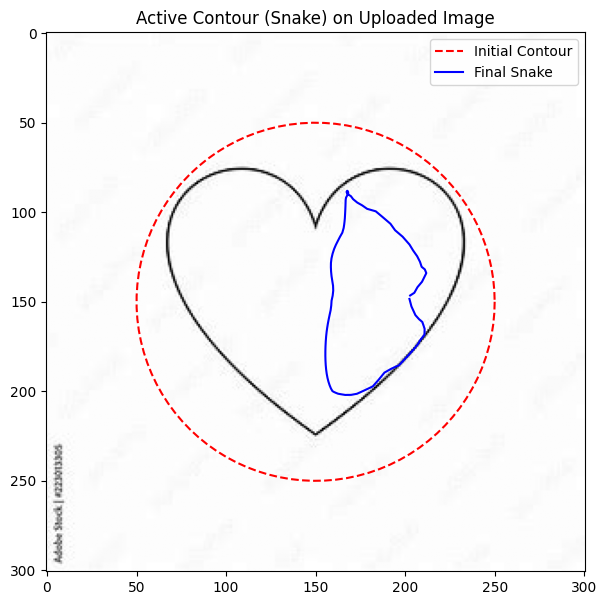

In [ ]:

# Apply Active Contour Model (Snakes)
snake = active_contour(smoothed_image, init_contour, alpha= 0.02, beta=15, gamma=0.001)

# Plot Results
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image, cmap='gray')
ax.plot(init_contour[:, 0], init_contour[:, 1], '--r', label="Initial Contour")  # Initial contour
ax.plot(snake[:, 0], snake[:, 1], '-b', label="Final Snake")  # Final contour
ax.legend()
ax.set_title("Active Contour (Snake) on Uploaded Image")
plt.show()
